# Análisis no supervisado K-means en el dataset Spotify

 * Objetivo

El objetivo de este notebook es encontrar patrones o grupos ocultos
utilizando técnicas de clustering para analizar sus características
musicales y estudiar posteriormente su distribución según la popularidad.

En esta etapa se realizan las siguientes operaciones:

* Matriz de correlación
* PCA
* Selección de parámetros para DBSCAN
* Evaluación de métricas de clustering
* Identificación de grupos y ruido
* Interpretación de perfiles musicales
* Análisis de popularidad por cluster

In [ ]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from sklearn.model_selection import train_test_split

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data = pd.read_csv("../../dataset/spotify_train_preprocesado_general.csv")

df = data.copy()

df.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


---

# Selección de componentes PCA

Con el fin de seleccionar el número de componentes adecuado y **corroborar su impacto en el análisis**, se utilizarán dos dataframes con distinta cantidad de componentes los cuales se componenen de la siguiente manera:

Dataframe 1:
* Número de componentes: 9 
* Varianza acumulada: 81,59%
* Representación de datos: 45%

Dataframe 2:
* Número de componentes: 13 
* Varianza acumulada: 90,81%
* Representación de datos: 65%

In [3]:
features_pca = [
    "bin__track_genre_0",
    "bin__track_genre_1",
    "bin__track_genre_2",
    "bin__track_genre_3",
    "bin__track_genre_4",
    "bin__track_genre_5",
    "bin__track_genre_6",
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

X_pca = df[features_pca]

In [4]:
pca1 = PCA(n_components=9)

pca2 = PCA(n_components=13)

X_pca_df1 = pca1.fit_transform(X_pca)

X_pca_df2 = pca2.fit_transform(X_pca)

In [5]:
print(
    "Varianza acumulada PCA 9:",
    round(pca1.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

print(
    "Varianza acumulada PCA 13:",
    round(pca2.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Varianza acumulada PCA 9: 81.59 %
Varianza acumulada PCA 13: 90.81 %


Creación del Dataframe con los componentes

In [6]:
df_pca_1 = pd.DataFrame(
    X_pca_df1,
    columns=[f"PC{i}" for i in range(1, pca1.n_components_ + 1)],
    index=df.index
)

df_pca_1["popularity_category"] = df["popularity_category"]


df_pca_2 = pd.DataFrame(
    X_pca_df2,
    columns=[f"PC{i}" for i in range(1, pca2.n_components_ + 1)],
    index=df.index
)

df_pca_2["popularity_category"] = df["popularity_category"]

In [7]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2


In [8]:
df_pca_2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,0.585176,-0.144823,0.062624,-0.054573,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0.571305,0.086036,0.044179,-0.056428,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,0.259746,-0.392587,-0.103014,-0.101921,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,-1.327553,0.229204,0.035569,-0.013113,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,0.443039,-0.276758,0.123554,0.287918,2


In [9]:
# 9 Dimensiones
X_cluster_1 = df_pca_1.drop(columns="popularity_category")

# 13 Dimensiones
X_cluster_2 = df_pca_2.drop(columns="popularity_category")

In [10]:
df_muestra_pca9, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

df_muestra_pca13, _ = train_test_split(
    df_pca_2,
    train_size=5000,
    stratify=df_pca_2["popularity_category"],
    random_state=42
)

In [11]:
X_muestra_pca9 = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
].copy()

X_muestra_pca13 = df_muestra_pca13[
    [f"PC{i}" for i in range(1, 14)]
].copy()

In [16]:
print("Distribución original PCA 9:")
print(df_pca_1["popularity_category"].value_counts(normalize=True))

print("\nDistribución muestra PCA 9:")
print(df_muestra_pca9["popularity_category"].value_counts(normalize=True))

print("\nDistribución original PCA 13:")
print(df_pca_2["popularity_category"].value_counts(normalize=True))

print("\nDistribución muestra PCA 13:")
print(df_muestra_pca13["popularity_category"].value_counts(normalize=True))

Distribución original PCA 9:
popularity_category
0    0.297189
2    0.291634
1    0.291623
3    0.111156
4    0.008398
Name: proportion, dtype: float64

Distribución muestra PCA 9:
popularity_category
0    0.2972
1    0.2916
2    0.2916
3    0.1112
4    0.0084
Name: proportion, dtype: float64

Distribución original PCA 13:
popularity_category
0    0.297189
2    0.291634
1    0.291623
3    0.111156
4    0.008398
Name: proportion, dtype: float64

Distribución muestra PCA 13:
popularity_category
0    0.2972
1    0.2916
2    0.2916
3    0.1112
4    0.0084
Name: proportion, dtype: float64


---

# Proceso de DBSCAN y selección de parámetros

DBSCAN identifica grupos de puntos densamente conectados.

Sus parámetros principales son:

* eps: distancia máxima para considerar vecinos.
* min_samples: cantidad mínima de puntos para formar una región densa.

Los puntos que no pertenecen a ningún grupo se etiquetan como ruido (-1).

## Análisis de distancias a los vecinos más cercanos

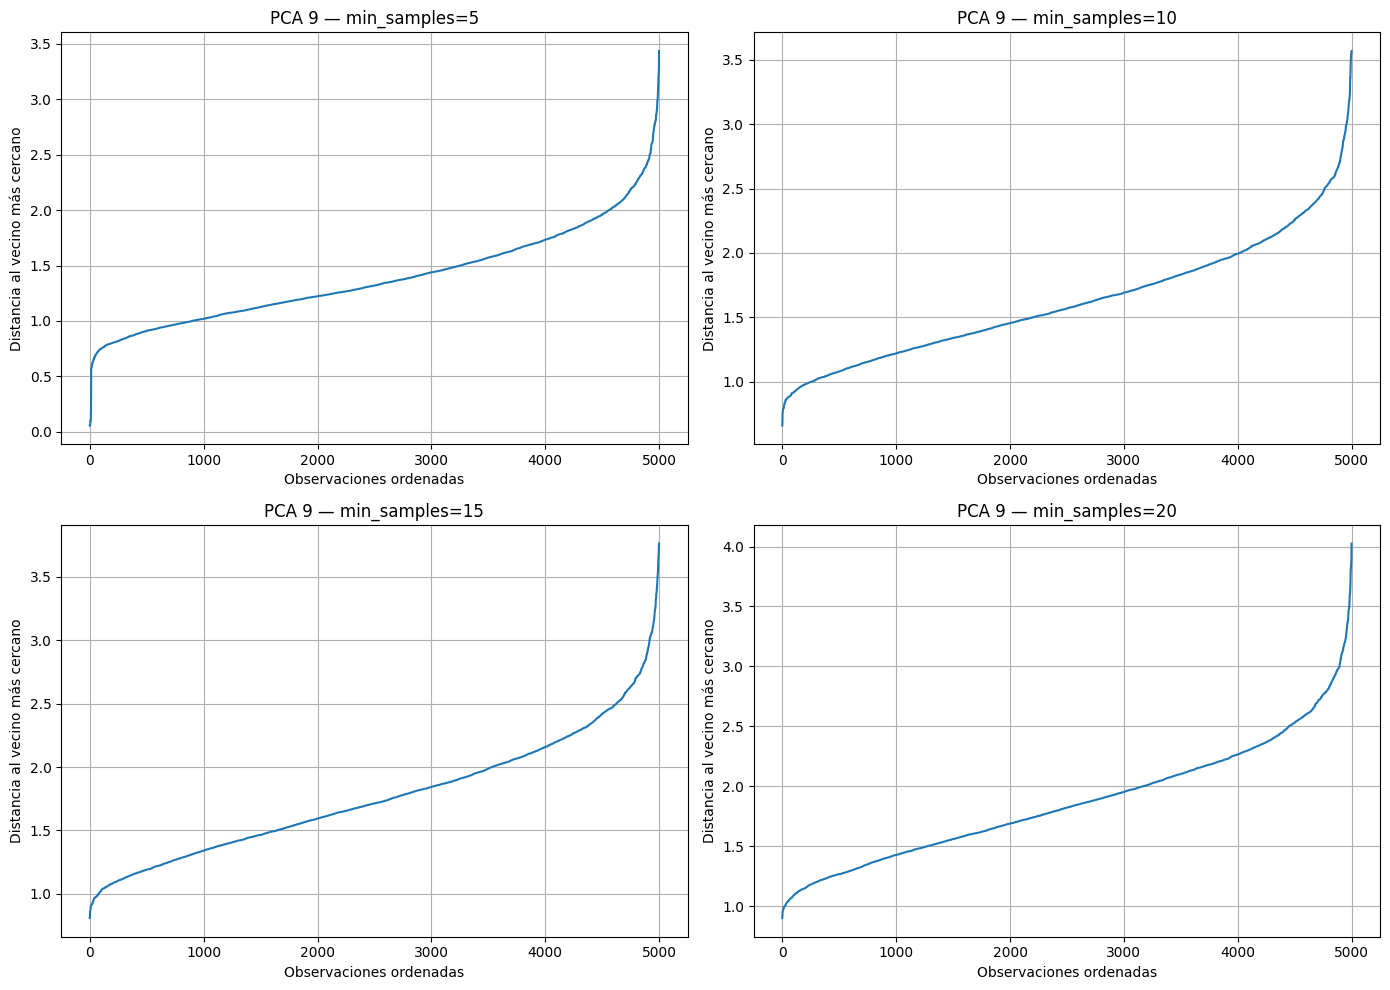

In [17]:
min_samples_values = [5, 10, 15, 20]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, min_samples in zip(axes.flatten(), min_samples_values):

    vecinos = NearestNeighbors(
        n_neighbors=min_samples
    )

    vecinos.fit(X_muestra_pca9)

    distancias, _ = vecinos.kneighbors(X_muestra_pca9)

    distancias_ordenadas = np.sort(distancias[:, -1])

    ax.plot(distancias_ordenadas)
    ax.set_title(f"PCA 9 — min_samples={min_samples}")
    ax.set_xlabel("Observaciones ordenadas")
    ax.set_ylabel("Distancia al vecino más cercano")
    ax.grid(True)

plt.tight_layout()
plt.show()

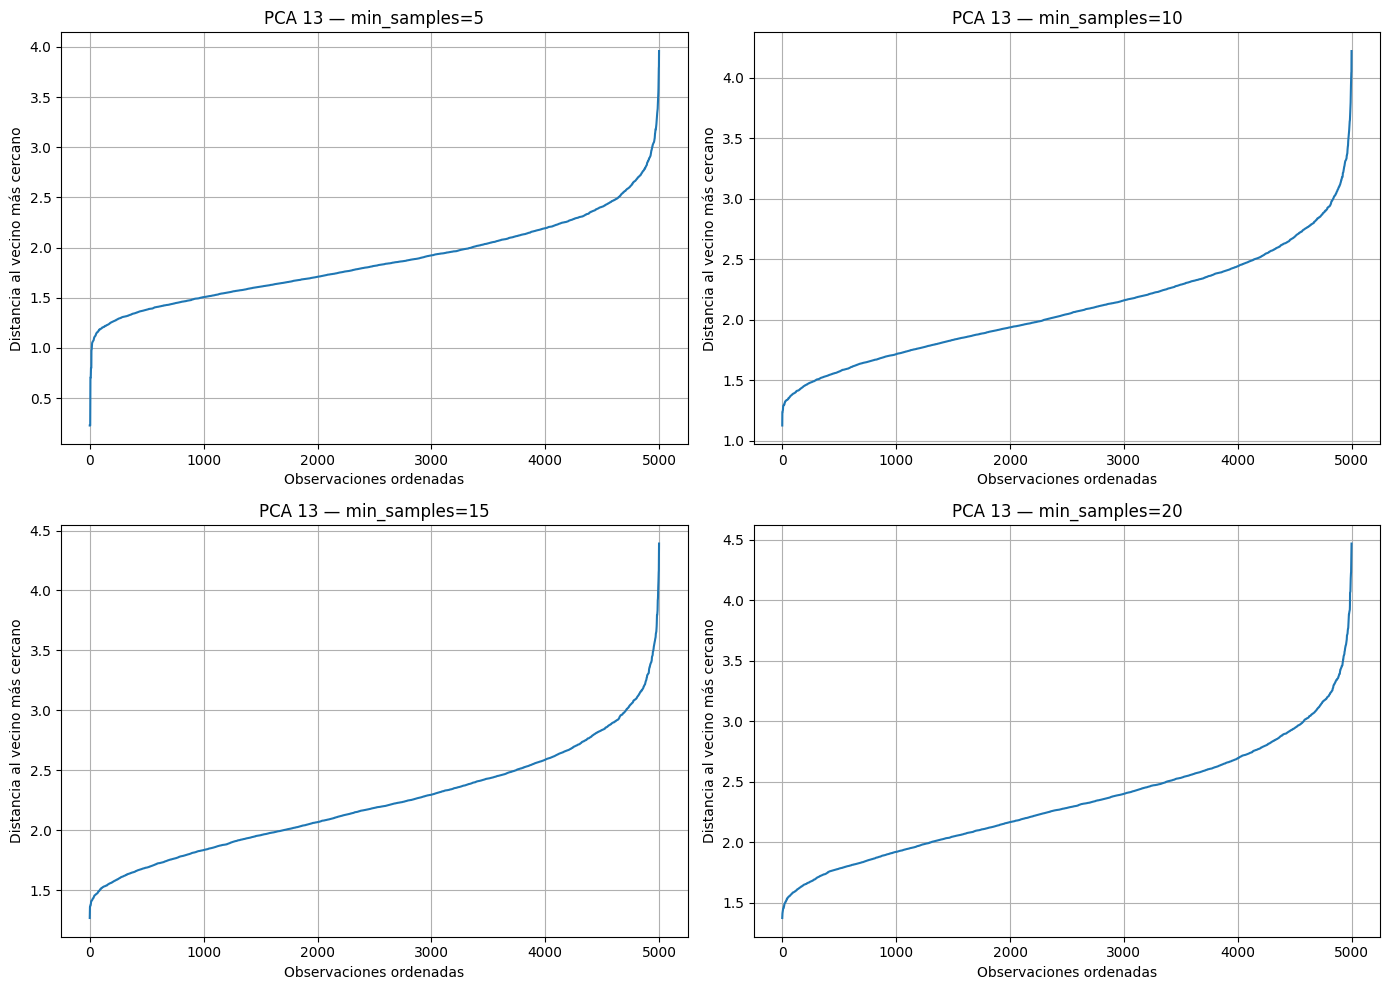

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, min_samples in zip(axes.flatten(), min_samples_values):

    vecinos = NearestNeighbors(
        n_neighbors=min_samples
    )

    vecinos.fit(X_muestra_pca13)

    distancias, _ = vecinos.kneighbors(X_muestra_pca13)

    distancias_ordenadas = np.sort(distancias[:, -1])

    ax.plot(distancias_ordenadas)
    ax.set_title(f"PCA 13 — min_samples={min_samples}")
    ax.set_xlabel("Observaciones ordenadas")
    ax.set_ylabel("Distancia al vecino más cercano")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Evaluación de combinaciones de eps y min_samples

Se evaluarán diferentes valores de eps derivados de los percentiles
de las distancias a los vecinos.

Las métricas internas se calculan excluyendo el ruido, ya que DBSCAN
asigna la etiqueta -1 a las observaciones que no pertenecen a un cluster.

In [19]:
percentiles_eps = [90, 92, 94, 95, 96, 97, 98, 99]

resultados_pca9 = []
resultados_pca13 = []

for min_samples in min_samples_values:

    # Distancias para PCA 9
    vecinos_pca9 = NearestNeighbors(
        n_neighbors=min_samples
    )

    vecinos_pca9.fit(X_muestra_pca9)

    distancias_pca9, _ = vecinos_pca9.kneighbors(
        X_muestra_pca9
    )

    distancias_ordenadas_pca9 = np.sort(
        distancias_pca9[:, -1]
    )

    # Distancias para PCA 13
    vecinos_pca13 = NearestNeighbors(
        n_neighbors=min_samples
    )

    vecinos_pca13.fit(X_muestra_pca13)

    distancias_pca13, _ = vecinos_pca13.kneighbors(
        X_muestra_pca13
    )

    distancias_ordenadas_pca13 = np.sort(
        distancias_pca13[:, -1]
    )

    for percentil in percentiles_eps:

        eps_pca9 = np.percentile(
            distancias_ordenadas_pca9,
            percentil
        )

        eps_pca13 = np.percentile(
            distancias_ordenadas_pca13,
            percentil
        )

        # DBSCAN para PCA 9
        modelo_pca9 = DBSCAN(
            eps=eps_pca9,
            min_samples=min_samples
        )

        labels_pca9 = modelo_pca9.fit_predict(
            X_muestra_pca9
        )

        mascara_pca9 = labels_pca9 != -1

        cantidad_clusters_pca9 = len(
            set(labels_pca9) - {-1}
        )

        cantidad_ruido_pca9 = np.sum(
            labels_pca9 == -1
        )

        porcentaje_ruido_pca9 = (
            cantidad_ruido_pca9 / len(labels_pca9)
        ) * 100

        silhouette_pca9 = np.nan
        calinski_pca9 = np.nan
        davies_pca9 = np.nan

        X_valido_pca9 = X_muestra_pca9.loc[
            mascara_pca9
        ]

        labels_validos_pca9 = labels_pca9[
            mascara_pca9
        ]

        if (
            cantidad_clusters_pca9 >= 2
            and len(X_valido_pca9) > cantidad_clusters_pca9
        ):

            silhouette_pca9 = silhouette_score(
                X_valido_pca9,
                labels_validos_pca9,
                sample_size=min(2000, len(X_valido_pca9)),
                random_state=42
            )

            calinski_pca9 = calinski_harabasz_score(
                X_valido_pca9,
                labels_validos_pca9
            )

            davies_pca9 = davies_bouldin_score(
                X_valido_pca9,
                labels_validos_pca9
            )

        resultados_pca9.append({
            "min_samples": min_samples,
            "percentil": percentil,
            "eps": eps_pca9,
            "clusters": cantidad_clusters_pca9,
            "ruido_pct": porcentaje_ruido_pca9,
            "Silhouette": silhouette_pca9,
            "Calinski-Harabasz": calinski_pca9,
            "Davies-Bouldin": davies_pca9
        })

        # DBSCAN para PCA 13
        modelo_pca13 = DBSCAN(
            eps=eps_pca13,
            min_samples=min_samples
        )

        labels_pca13 = modelo_pca13.fit_predict(
            X_muestra_pca13
        )

        mascara_pca13 = labels_pca13 != -1

        cantidad_clusters_pca13 = len(
            set(labels_pca13) - {-1}
        )

        cantidad_ruido_pca13 = np.sum(
            labels_pca13 == -1
        )

        porcentaje_ruido_pca13 = (
            cantidad_ruido_pca13 / len(labels_pca13)
        ) * 100

        silhouette_pca13 = np.nan
        calinski_pca13 = np.nan
        davies_pca13 = np.nan

        X_valido_pca13 = X_muestra_pca13.loc[
            mascara_pca13
        ]

        labels_validos_pca13 = labels_pca13[
            mascara_pca13
        ]

        if (
            cantidad_clusters_pca13 >= 2
            and len(X_valido_pca13) > cantidad_clusters_pca13
        ):

            silhouette_pca13 = silhouette_score(
                X_valido_pca13,
                labels_validos_pca13,
                sample_size=min(2000, len(X_valido_pca13)),
                random_state=42
            )

            calinski_pca13 = calinski_harabasz_score(
                X_valido_pca13,
                labels_validos_pca13
            )

            davies_pca13 = davies_bouldin_score(
                X_valido_pca13,
                labels_validos_pca13
            )

        resultados_pca13.append({
            "min_samples": min_samples,
            "percentil": percentil,
            "eps": eps_pca13,
            "clusters": cantidad_clusters_pca13,
            "ruido_pct": porcentaje_ruido_pca13,
            "Silhouette": silhouette_pca13,
            "Calinski-Harabasz": calinski_pca13,
            "Davies-Bouldin": davies_pca13
        })

resultados_pca9 = pd.DataFrame(resultados_pca9)
resultados_pca13 = pd.DataFrame(resultados_pca13)

print("RESULTADOS — PCA 9")
display(resultados_pca9.round(4))

print("\nRESULTADOS — PCA 13")
display(resultados_pca13.round(4))

RESULTADOS — PCA 9


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,1.9604,4,3.72,0.0747,175.5583,1.9186
1,5,92,2.0270,4,2.76,0.0698,172.5801,1.8948
2,5,94,2.1132,1,2.08,NaN,NaN,NaN
3,5,95,2.1907,1,1.56,NaN,NaN,NaN
4,5,96,2.2522,1,1.30,NaN,NaN,NaN
5,5,97,2.3276,1,0.92,NaN,NaN,NaN
6,5,98,2.4358,1,0.68,NaN,NaN,NaN
7,5,99,2.6903,1,0.20,NaN,NaN,NaN
8,10,90,2.2548,1,2.16,NaN,NaN,NaN
9,10,92,2.3307,1,1.62,NaN,NaN,NaN



RESULTADOS — PCA 13


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,2.4076,2,3.24,0.1797,3.9172,0.8431
1,5,92,2.4702,1,2.54,NaN,NaN,NaN
2,5,94,2.5635,1,1.86,NaN,NaN,NaN
3,5,95,2.6145,1,1.46,NaN,NaN,NaN
4,5,96,2.6778,1,1.16,NaN,NaN,NaN
5,5,97,2.7439,1,0.82,NaN,NaN,NaN
6,5,98,2.8551,1,0.60,NaN,NaN,NaN
7,5,99,3.0421,1,0.18,NaN,NaN,NaN
8,10,90,2.6860,1,1.78,NaN,NaN,NaN
9,10,92,2.7579,1,1.32,NaN,NaN,NaN


In [20]:
resultados_pca9_ordenados = resultados_pca9.sort_values(
    by="Silhouette",
    ascending=False,
    na_position="last"
)

resultados_pca13_ordenados = resultados_pca13.sort_values(
    by="Silhouette",
    ascending=False,
    na_position="last"
)

print("MEJORES CONFIGURACIONES — PCA 9")
display(resultados_pca9_ordenados.head(15).round(4))

print("MEJORES CONFIGURACIONES — PCA 13")
display(resultados_pca13_ordenados.head(15).round(4))

MEJORES CONFIGURACIONES — PCA 9


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,1.9604,4,3.72,0.0747,175.5583,1.9186
1,5,92,2.0270,4,2.76,0.0698,172.5801,1.8948
2,5,94,2.1132,1,2.08,NaN,NaN,NaN
3,5,95,2.1907,1,1.56,NaN,NaN,NaN
4,5,96,2.2522,1,1.30,NaN,NaN,NaN
5,5,97,2.3276,1,0.92,NaN,NaN,NaN
6,5,98,2.4358,1,0.68,NaN,NaN,NaN
7,5,99,2.6903,1,0.20,NaN,NaN,NaN
8,10,90,2.2548,1,2.16,NaN,NaN,NaN
9,10,92,2.3307,1,1.62,NaN,NaN,NaN


MEJORES CONFIGURACIONES — PCA 13


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,2.4076,2,3.24,0.1797,3.9172,0.8431
1,5,92,2.4702,1,2.54,NaN,NaN,NaN
2,5,94,2.5635,1,1.86,NaN,NaN,NaN
3,5,95,2.6145,1,1.46,NaN,NaN,NaN
4,5,96,2.6778,1,1.16,NaN,NaN,NaN
5,5,97,2.7439,1,0.82,NaN,NaN,NaN
6,5,98,2.8551,1,0.60,NaN,NaN,NaN
7,5,99,3.0421,1,0.18,NaN,NaN,NaN
8,10,90,2.6860,1,1.78,NaN,NaN,NaN
9,10,92,2.7579,1,1.32,NaN,NaN,NaN


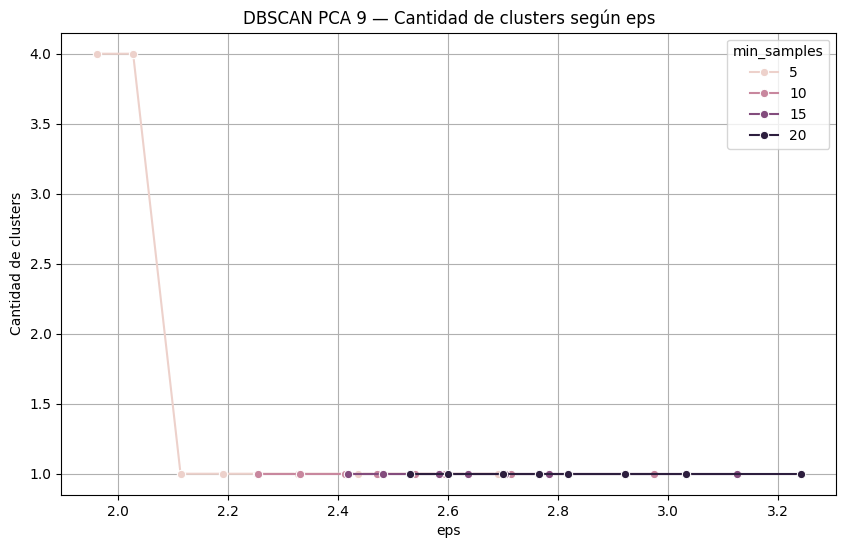

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=resultados_pca9,
    x="eps",
    y="clusters",
    hue="min_samples",
    marker="o",
    ax=ax
)

ax.set_title("DBSCAN PCA 9 — Cantidad de clusters según eps")
ax.set_xlabel("eps")
ax.set_ylabel("Cantidad de clusters")
ax.grid(True)

plt.show()

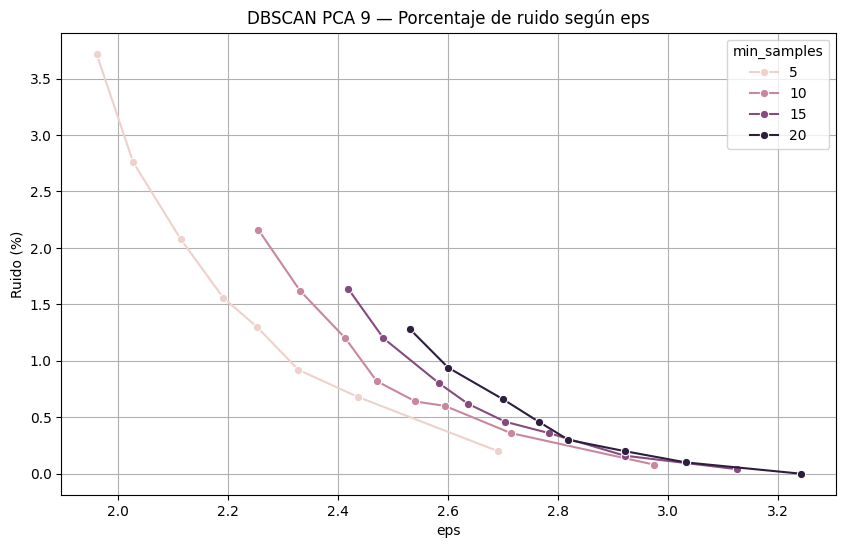

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=resultados_pca9,
    x="eps",
    y="ruido_pct",
    hue="min_samples",
    marker="o",
    ax=ax
)

ax.set_title("DBSCAN PCA 9 — Porcentaje de ruido según eps")
ax.set_xlabel("eps")
ax.set_ylabel("Ruido (%)")
ax.grid(True)

plt.show()

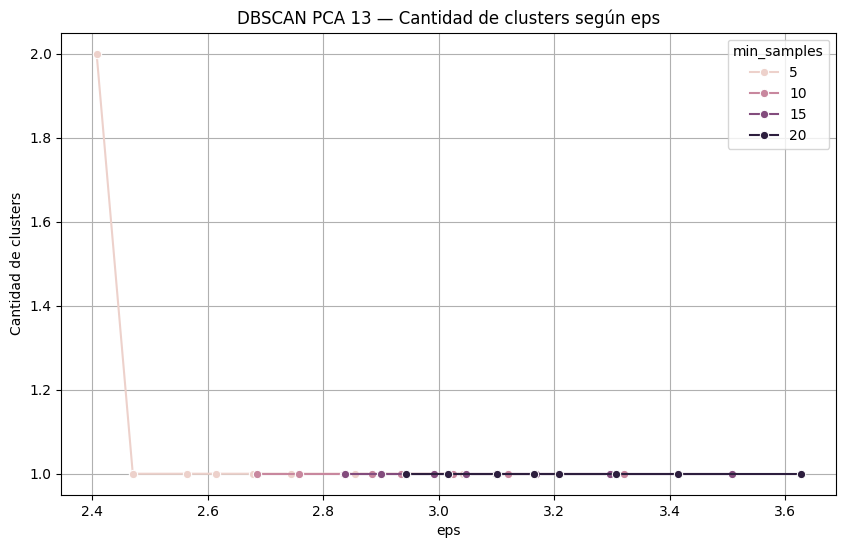

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=resultados_pca13,
    x="eps",
    y="clusters",
    hue="min_samples",
    marker="o",
    ax=ax
)

ax.set_title("DBSCAN PCA 13 — Cantidad de clusters según eps")
ax.set_xlabel("eps")
ax.set_ylabel("Cantidad de clusters")
ax.grid(True)

plt.show()

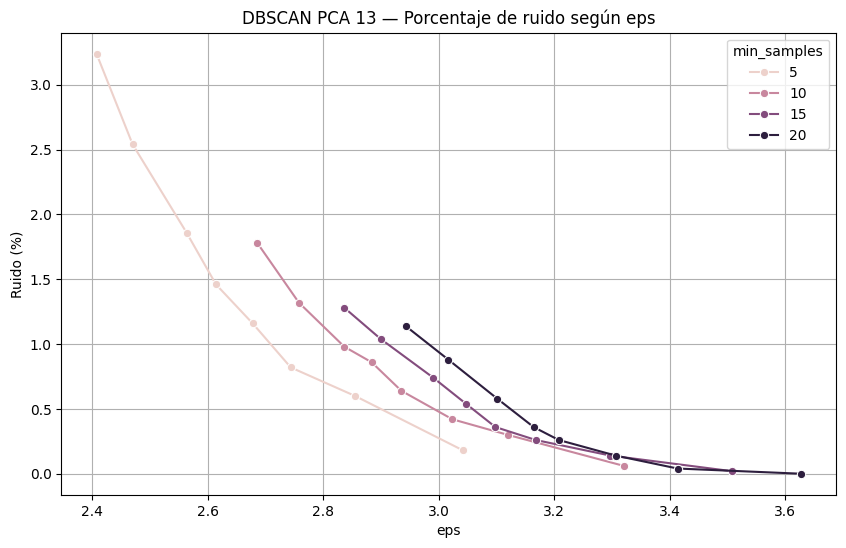

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=resultados_pca13,
    x="eps",
    y="ruido_pct",
    hue="min_samples",
    marker="o",
    ax=ax
)

ax.set_title("DBSCAN PCA 13 — Porcentaje de ruido según eps")
ax.set_xlabel("eps")
ax.set_ylabel("Ruido (%)")
ax.grid(True)

plt.show()

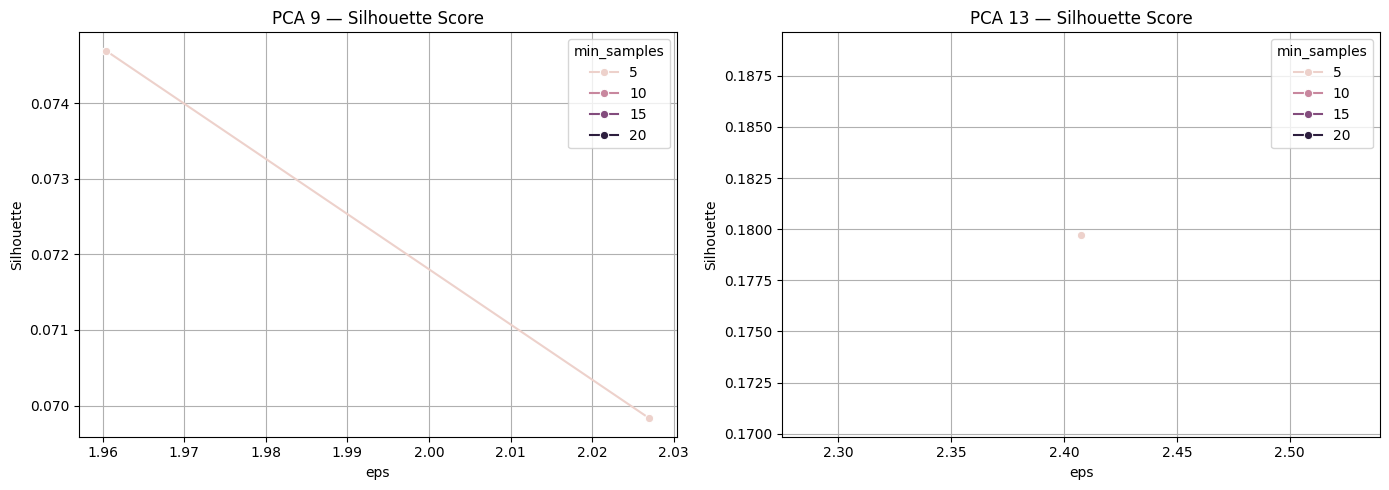

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=resultados_pca9,
    x="eps",
    y="Silhouette",
    hue="min_samples",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("PCA 9 — Silhouette Score")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Silhouette")
axes[0].grid(True)

sns.lineplot(
    data=resultados_pca13,
    x="eps",
    y="Silhouette",
    hue="min_samples",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("PCA 13 — Silhouette Score")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True)

plt.tight_layout()
plt.show()

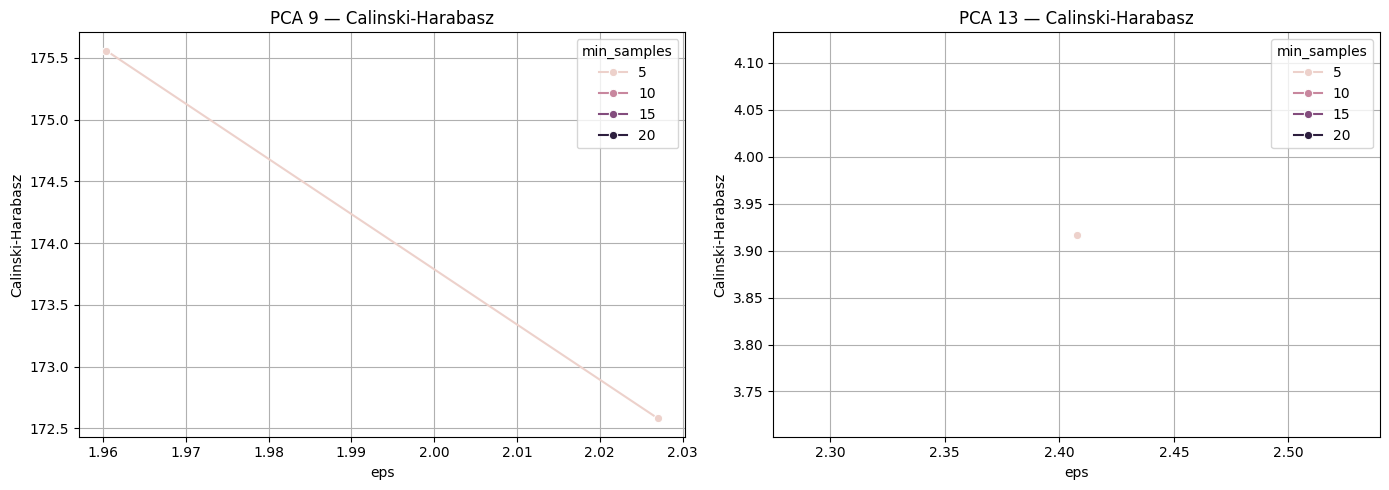

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=resultados_pca9,
    x="eps",
    y="Calinski-Harabasz",
    hue="min_samples",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("PCA 9 — Calinski-Harabasz")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Calinski-Harabasz")
axes[0].grid(True)

sns.lineplot(
    data=resultados_pca13,
    x="eps",
    y="Calinski-Harabasz",
    hue="min_samples",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("PCA 13 — Calinski-Harabasz")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Calinski-Harabasz")
axes[1].grid(True)

plt.tight_layout()
plt.show()

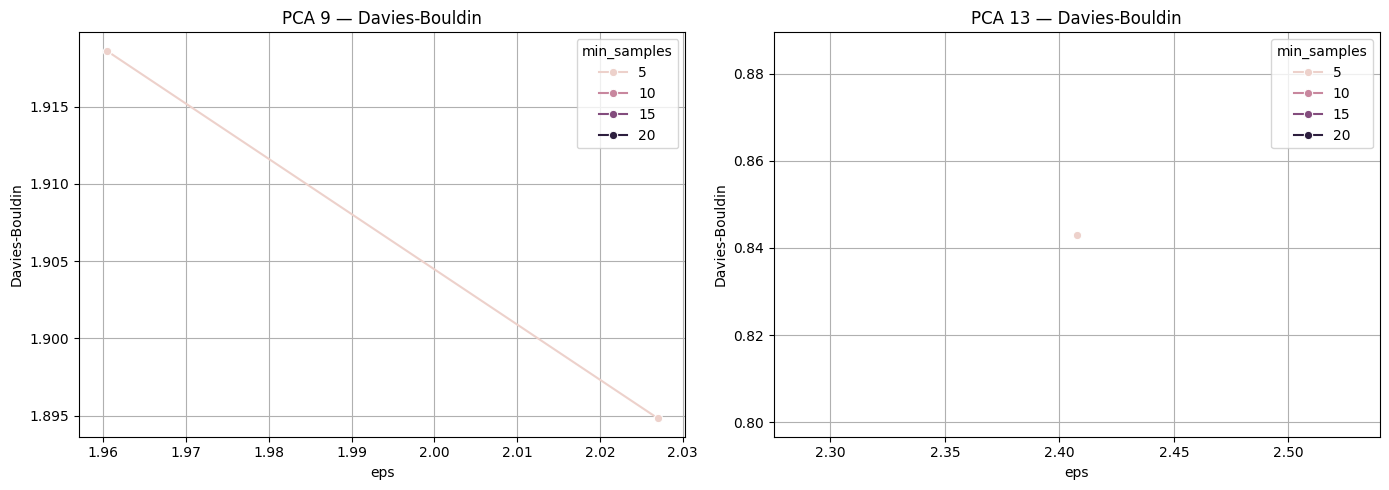

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=resultados_pca9,
    x="eps",
    y="Davies-Bouldin",
    hue="min_samples",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("PCA 9 — Davies-Bouldin")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Davies-Bouldin")
axes[0].grid(True)

sns.lineplot(
    data=resultados_pca13,
    x="eps",
    y="Davies-Bouldin",
    hue="min_samples",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("PCA 13 — Davies-Bouldin")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Davies-Bouldin")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [28]:
candidatos_pca9 = resultados_pca9[
    (resultados_pca9["clusters"] >= 2)
    & (resultados_pca9["ruido_pct"] < 50)
    & (resultados_pca9["Silhouette"].notna())
].sort_values(
    by="Silhouette",
    ascending=False
)

candidatos_pca13 = resultados_pca13[
    (resultados_pca13["clusters"] >= 2)
    & (resultados_pca13["ruido_pct"] < 50)
    & (resultados_pca13["Silhouette"].notna())
].sort_values(
    by="Silhouette",
    ascending=False
)

print("CANDIDATOS PCA 9")
display(candidatos_pca9.head(15).round(4))

print("CANDIDATOS PCA 13")
display(candidatos_pca13.head(15).round(4))

CANDIDATOS PCA 9


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,1.9604,4,3.72,0.0747,175.5583,1.9186
1,5,92,2.0270,4,2.76,0.0698,172.5801,1.8948


CANDIDATOS PCA 13


,min_samples,percentil,eps,clusters,ruido_pct,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,90,2.4076,2,3.24,0.1797,3.9172,0.8431


In [29]:
if candidatos_pca9.empty:
    print(
        "No se encontraron configuraciones para PCA 9 que cumplan "
        "los criterios establecidos."
    )
else:
    mejor_configuracion_pca9 = candidatos_pca9.iloc[0]

    print("Mejor configuración PCA 9:")
    print("eps:", mejor_configuracion_pca9["eps"])
    print("min_samples:", mejor_configuracion_pca9["min_samples"])
    print("Clusters:", mejor_configuracion_pca9["clusters"])
    print("Ruido (%):", mejor_configuracion_pca9["ruido_pct"])
    print("Silhouette:", mejor_configuracion_pca9["Silhouette"])

Mejor configuración PCA 9:
eps: 1.9604114801022694
min_samples: 5.0
Clusters: 4.0
Ruido (%): 3.7199999999999998
Silhouette: 0.07469716978685927


In [30]:
# Selección de la mejor configuración de DBSCAN
eps_mejor = mejor_configuracion_pca9["eps"]
min_samples_mejor = int(mejor_configuracion_pca9["min_samples"])

# Entrenamiento de DBSCAN con PCA de 9 componentes
dbscan_pca9 = DBSCAN(
    eps=eps_mejor,
    min_samples=min_samples_mejor
)

clusters_pca9 = dbscan_pca9.fit_predict(X_muestra_pca9)

# DataFrame para visualizar los grupos
df_plotly_pca9 = df_muestra_pca9.copy()
df_plotly_pca9["cluster"] = clusters_pca9.astype(str)
df_plotly_pca9["cluster"] = df_plotly_pca9["cluster"].replace(
    {"-1": "Ruido"}
)

# Visualización interactiva en 3D
fig = px.scatter_3d(
    df_plotly_pca9,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    symbol="cluster",
    hover_data=["popularity_category"],
    title="Visualización de grupos DBSCAN — PCA de 9 componentes",
    labels={
        "PC1": "Componente principal 1",
        "PC2": "Componente principal 2",
        "PC3": "Componente principal 3",
        "cluster": "Grupo"
    },
    opacity=0.7
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(
    template="plotly_white",
    legend_title_text="Grupo DBSCAN",
    height=750
)

fig.show()

In [31]:
# Obtener las filas correspondientes a la muestra utilizada por DBSCAN
indices_muestra_pca9 = df_muestra_pca9.index

df_caracteristicas_pca9 = df.loc[indices_muestra_pca9, features_pca].copy()
df_caracteristicas_pca9["cluster"] = clusters_pca9

# Excluir los puntos clasificados como ruido
df_caracteristicas_sin_ruido = df_caracteristicas_pca9[
    df_caracteristicas_pca9["cluster"] != -1
].copy()

# Calcular las características promedio de cada grupo
resumen_clusters = df_caracteristicas_sin_ruido.groupby("cluster")[features_pca].mean()

display(resumen_clusters.round(3))

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min
cluster,,,,,,,,,,,,,,,,,,,,
0,0.468,0.422,0.444,0.481,0.482,0.500,0.511,-0.047,-0.036,-0.029,-0.095,0.010,0.751,-0.100,0.055,-0.088,-0.000,0.058,0.030,-0.050
1,0.439,0.506,0.459,0.518,0.477,0.499,0.480,0.089,0.143,0.168,0.196,0.148,-1.331,0.096,-0.205,0.028,-0.073,-0.016,-0.018,0.090
2,0.800,0.800,0.000,0.200,0.200,0.200,0.200,2.215,-2.080,0.778,-0.424,-0.301,0.751,-0.080,-0.755,1.794,1.504,-1.553,-0.845,2.290
3,0.667,0.000,0.222,0.111,0.667,0.778,0.111,1.356,-0.173,0.680,0.912,0.261,0.751,2.030,1.303,-0.607,2.410,-0.214,-0.598,1.539


In [32]:
df_resumen_plotly = resumen_clusters.reset_index().melt(
    id_vars="cluster",
    var_name="Característica",
    value_name="Promedio"
)

fig = px.bar(
    df_resumen_plotly,
    x="Característica",
    y="Promedio",
    color="cluster",
    barmode="group",
    title="Comparación de características promedio por grupo DBSCAN",
    labels={
        "cluster": "Grupo",
        "Característica": "Característica de la canción",
        "Promedio": "Valor promedio"
    },
    hover_data={"Promedio": ":.3f"}
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    height=650
)

fig.show()

In [ ]:
# Estandarizar los promedios por característica
valores_estandarizados = StandardScaler().fit_transform(
    resumen_clusters.T
).T

df_heatmap = pd.DataFrame(
    valores_estandarizados,
    index=resumen_clusters.index,
    columns=resumen_clusters.columns
)

fig = px.imshow(
    df_heatmap,
    x=df_heatmap.columns,
    y=[f"Grupo {cluster}" for cluster in df_heatmap.index],
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    aspect="auto",
    title="Perfil relativo de características por grupo DBSCAN",
    labels={
        "x": "Característica",
        "y": "Grupo",
        "color": "Valor estandarizado"
    }
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    height=500
)

fig.show()